# **1. Introduzione e Sfide del Dataset**
Il task richiede la classificazione di testi in 7 categorie (6 stereotipi + NO). La sfida principale è la natura Small Data del problema: il dataset fornito contiene circa 200 esempi.
Inoltre, durante una prima esplorazione, abbiamo notato che la distribuzione delle classi era fortemente sbilanciata e che alcune annotazioni originali sembravano incoerenti (es. frasi neutre etichettate come stereotipo).

Prima di procedere con la modellistica, abbiamo affrontato la qualità dei dati.

# **2. Data Engineering: Cleaning & Augmentation**
**2.1 Human-in-the-loop Data Cleaning**
Dato che il dataset è piccolo, la qualità di ogni singola label è cruciale. Abbiamo notato nei primi test che tra gli errori peggiori del modello, spesso molti erano causati da annotazioni a nostro parere errate, commenti annotati come non stereotipati ma che in realtà contenevano uno stereotipo.
Abbiamo implementato una procedura di pulizia assistita da LLM:

Abbiamo fornito le linee guida del task a un LLM.

Abbiamo chiesto di analizzare il dataset e segnalare i casi in cui l'etichetta assegnata fosse in forte disaccordo con la definizione della categoria.

Revisione Manuale: Abbiamo controllato manualmente solo i casi segnalati e rimosso o corretto quelli effettivamente errati. Questo ha ridotto il rumore nel training set.

**2.2 Data Augmentation Semantica**
Per mitigare lo sbilanciamento delle classi (es. Sexual e Relational con pochissimi esempi), abbiamo evitato il semplice oversampling (che duplica i dati portando a overfitting).
Abbiamo adottato tecniche di data agumentation. Inizialmente abbiamo provato con la tecnica di back translation, traducendo tutti i dati in inglese e poi di nuovo in italiano, per cqmbiare alcune parole mantemendo lo stesso significato della frase, ma ottenendo risultati peggiori, abbiamo poi dunque provato il data agumentation generando dati sintetici tramite LLM, chiedendo di creare variazioni sintattiche dei commenti delle classi minoritarie mantenendo inalterato il significato semantico e lo stereotipo di riferimento.

# **Prompt del'LLM per data agumentation**

Agisci come un esperto di linguistica computazionale per l'analisi di hate speech su social media. Ti darò una lista di commenti reali (JSONL). Per ogni commento, genera il numero di varianti richiesto che mantengano ESATTAMENTE lo stesso stereotipo (o la sua assenza) ma cambiando lessico e sintassi.

*[Qui abbiamo mandato anche la lista degli stereotipi opresenti nelle specifiche del task con la spiegazione di ogni classe di stereotipo]*

IMPORTANTE:
Se è presente nell'originale mantieni lo stile da social network (usa slang, abbreviazioni come 'ke' invece di 'che', punteggiatura eccessiva '!!!', emoji).

Se l'originale è sgrammaticato, anche la variante deve sembrare colloquiale.
Non rendere il testo 'robotico' o troppo pulito.

Restituisci il risultato  solo in formato JSONL rigoroso che rispecchia lo stesso formato del dataset originale, generando esattamente questa quantità di varianti per ogni commento, non meno:

TARGET:
- Se il commento è classe 'sexual' o 'relational': genera 5 varianti.
- Se classe 'physical': genera 3 varianti.
- Se classe 'personality', 'competence' o 'role': genera 1 variante.
- Se classe 'no': NON generare nulla.

# **3. Fase I: L'approccio Deep Learning (BERT & Nested CV)**
La nostra prima ipotesi è stata utilizzare un modello dbmdz/bert-base-italian-cased con una strategia di validazione robusta per compensare i pochi dati: la Nested Cross-Validation.

# **3.1 Primo Tentativo: Epoch AveragingInizialmente**
Per sfruttare al massimo i dati, abbiamo strutturato il training così:

Inner Folds: Usati per trovare l'iperparametro ottimale, ovvero il numero di epoche ($E_{best}$) in cui la loss di validazione era minima, trovato facendo la media delle migliori epoche dei modelli degli inner folds.

Retraining: Abbiamo riaddestrato il modello sull'intero Outer Fold (senza validation set) per esattamente $E_{best}$ epoche, testandolo poi sul test set esterno.

Risultato: Continuavamo ad avere un F1-Score molto basso, in oltre la tecnica non era buona per il nostro piccolo dataset in cui la loss scendeva non in maniera fluida, perchè l'ultima epoca poteva essere spesso molto peggiore rispetto alla precedente o quella che sarebbe stata la successiva.

# **3.2 Secondo Tentativo: Knowledge Distillation con Recovery Mode**
Dato l'overfitting riscontrato con il training classico, abbiamo implementato una pipeline di Knowledge Distillation (KD) integrata nella Nested CV. Anche perchè volevamo provare un metodo che sfruttasse i risultati di addestramento ottenuti dagli inner fold invece che usarli solo per decidere l'epoca migliore.
L'ipotesi era che un insieme di modelli "Teacher", addestrati su sotto-insiemi dei dati (inner folds), potesse generare delle soft labels (distribuzioni di probabilità) capaci di trasferire "conoscenza oscura" (dark knowledge) a un modello "Student" finale, rendendolo più robusto.

**Architettura della Soluzione:**

Teacher Ensemble: Per ogni Outer Fold, addestriamo 4 Teacher sugli Inner Fold.

Student Training: Lo Student impara minimizzando una loss combinata (CrossEntropy sui dati reali + KL-Divergence sui logit dei Teacher).

Ecco una sintesi del codice implementato per la funzione di loss distillata e la logica di recovery:

In [ ]:
'''
# Sintesi del codice di Training (Knowledge Distillation)
# Questo loop allena il modello "Student" imparando sia dalle etichette reali (Hard Loss)
# sia dalle probabilità del "Teacher" (Soft Loss / Distillation)

def train_student_distilled(model, loader, optimizer, device, T, alpha):
    """
    T = Temperature (ammorbidisce le probabilità per trasferire più informazione)
    alpha = Peso della Distillation Loss vs Hard Loss
    """
    kldiv_loss_fn = nn.KLDivLoss(reduction="batchmean")
    hard_loss_fn = nn.CrossEntropyLoss()

    model.train()
    for batch in loader:
        ids = batch['ids'].to(device)
        targets = batch['target'].to(device)       # Hard Labels (Verità: 0..6)
        teacher_logits = batch['teacher_logits'].to(device) # Soft Labels (Logits dai Teacher)

        optimizer.zero_grad()
        student_logits = model(ids, batch['mask'], batch['token_type_ids'])

        # 1. Hard Loss (Impara dai dati reali)
        loss_hard = hard_loss_fn(student_logits, targets)

        # 2. Knowledge Distillation Loss (Impara a imitare i Teacher)
        # Applichiamo la temperatura T per ammorbidire la distribuzione
        student_soft = F.log_softmax(student_logits / T, dim=1)
        teacher_soft = F.softmax(teacher_logits / T, dim=1)
        loss_kd = kldiv_loss_fn(student_soft, teacher_soft) * (T * T)

        # Loss Combinata
        loss = (alpha * loss_kd) + ((1 - alpha) * loss_hard)

        loss.backward()
        optimizer.step()

# Logica di Inference
def predict_multiclass(model, batch):
    """
    Esegue la predizione diretta su 7 classi (0=NO, 1-6=Stereotipi)
    senza passare per filtri binari.
    """
    model.eval()
    with torch.no_grad():
        # Calcolo dei logits
        logits = model(batch['ids'], batch['mask'], batch['token_type_ids'])

        # Predizione finale: classe con probabilità più alta
        final_preds = torch.argmax(logits, dim=1).cpu().tolist()

    return final_preds
    '''

# **3.3 Risultati Knowledge Distillation**
Nonostante la complessità architetturale, i risultati non sono migliorati significativamente rispetto alla baseline.
La Confusion Matrix (sotto) mostra che il modello soffre ancora di una confusione nel classificare la classe NO. Le classi minoritarie come SEXUAL e RELATIONAL sono quasi completamente errate.

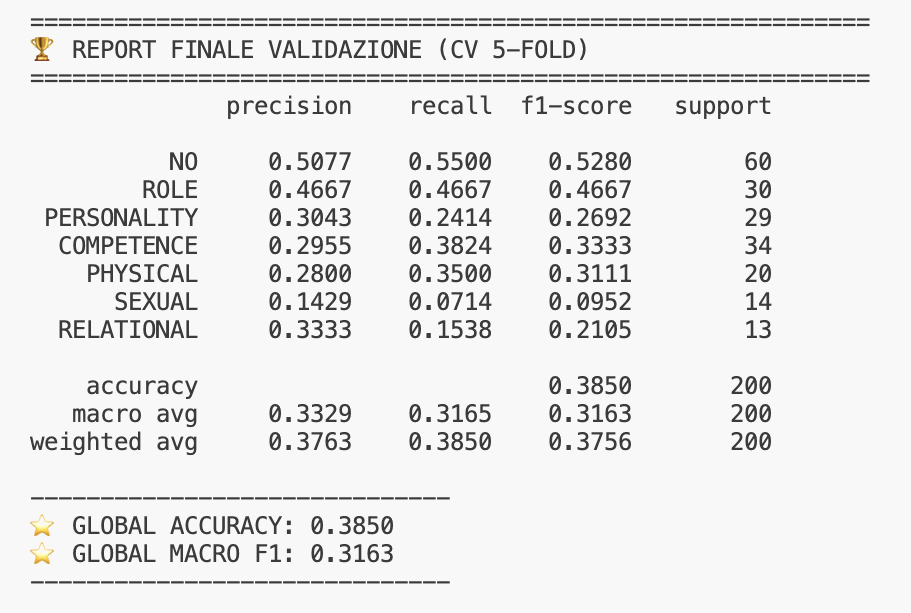

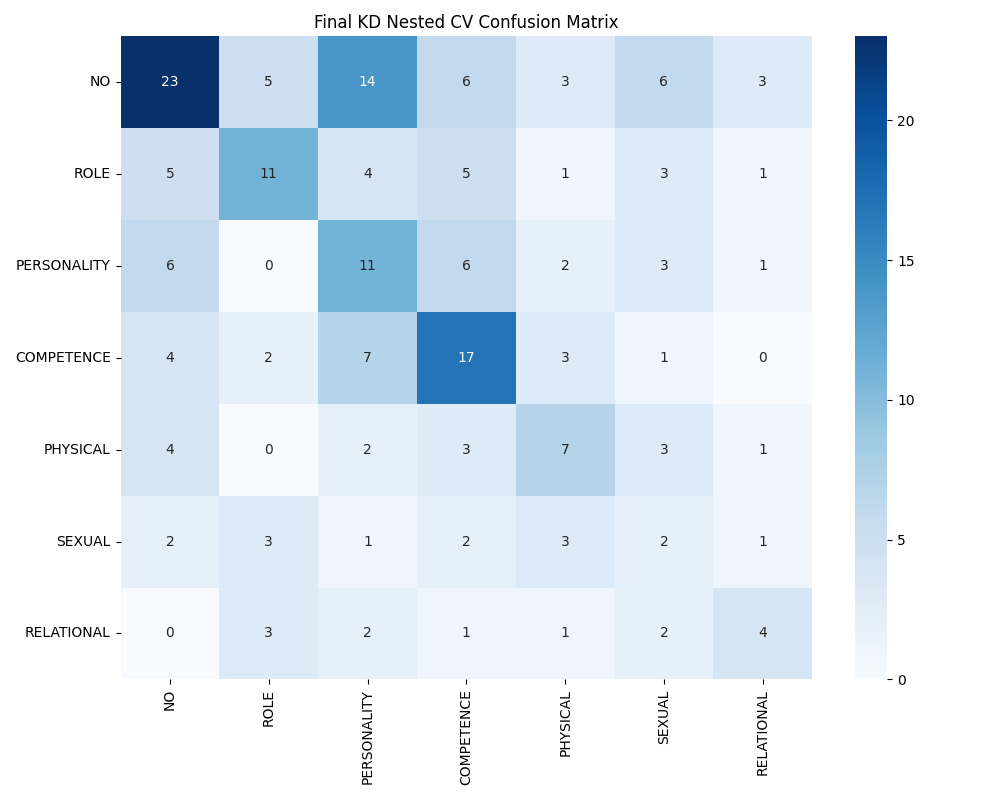

# **4. Analisi degli Errori e della Soglia**
Nonostante la Distillation, i risultati rimanevano insoddisfacenti. Un problema ricorrente era l'alto numero di Falsi Positivi (testi "NO" classificati come stereotipi).

Prima di cambiare architettura, ci siamo chiesti se potessimo risolvere il problema alzando la soglia di confidenza.
Abbiamo stampato la distribuzione delle probabilità per le predizioni errate.

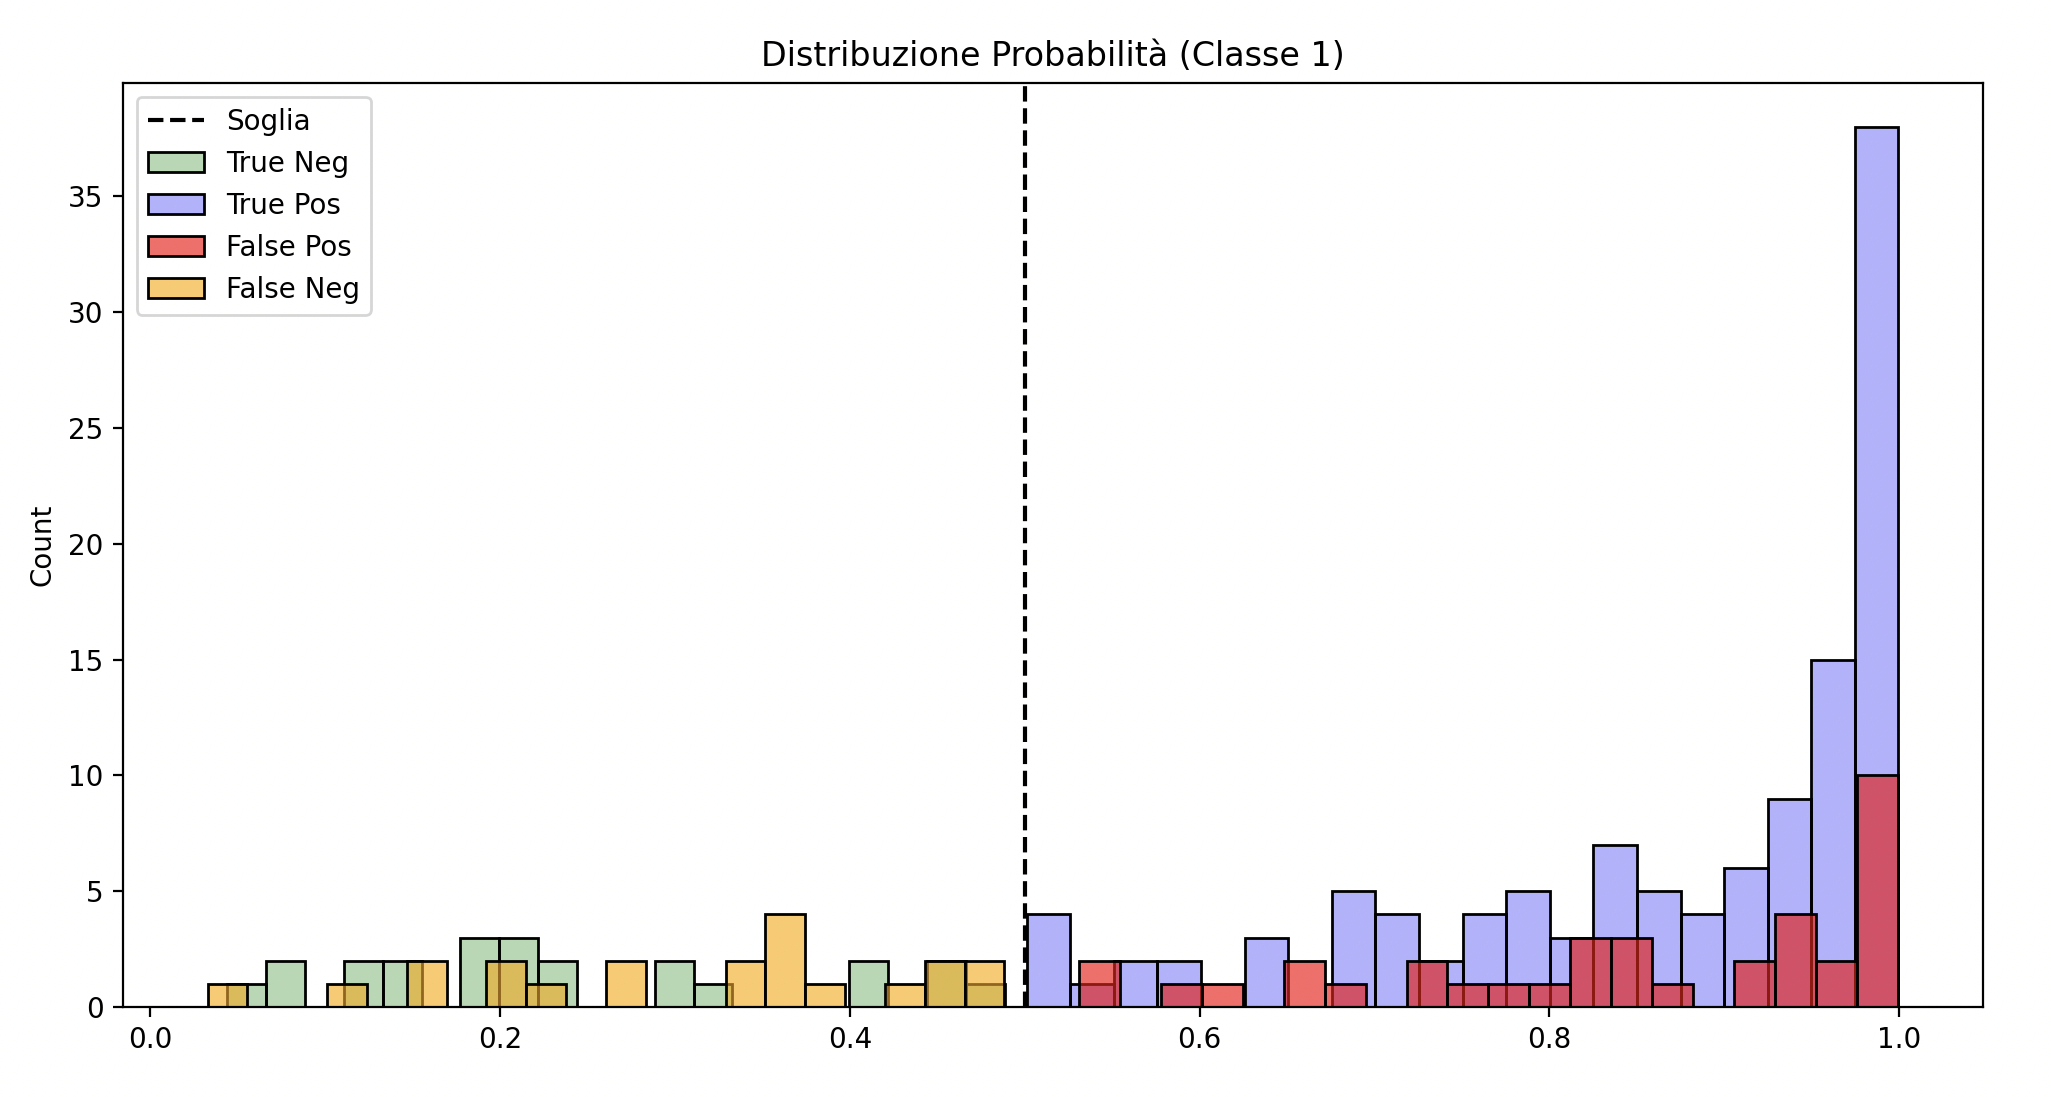

**Osservazione:**
Il grafico mostra che gli errori di falsi positivi (barre rosse) non si concentrano nella zona di incertezza (es. probabilità 0.5 - 0.6), ma sono spostati verso 1.0.

**Conclusione:** Il modello è "confidently wrong". Alzare la soglia non eliminerebbe gli errori senza eliminare anche gran parte delle predizioni corrette. Questo ci ha confermato che il problema era strutturale.

# **4.1 L'Evoluzione dell'Architettura: Dalla Soglia alla Pipeline**
Dato che la semplice manipolazione della soglia di confidenza sarebbe stata inefficace (il modello era "confidently wrong"), abbiamo ipotizzato che il compito fosse troppo complesso per un singolo classificatore. La distinzione tra "Nessuno Stereotipo" e "Presenza di Stereotipo" è semanticamente diversa dal distinguere quale stereotipo sia presente. Abbiamo quindi sperimentato un approccio a stadi (Pipeline):

**1. Tentativo A: Pipeline Rigida (Binario + 6 Classi)**

Abbiamo addestrato due modelli distinti:

Modello Binario: Classifica Input $\rightarrow$ [NO, SI].

Modello Specifico (6 Classi): Classifica Input $\rightarrow$ [ROLE, PERSONALITY, ..., RELATIONAL] (senza la classe NO).

Logica: Se il binario prediceva "SI", l'input passava al secondo modello per l'etichettatura fine.

Risultato: Buono ma c'erano ancora falsi positivi. Se il modello binario commetteva un errore classificando un Falso Positivo (diceva "SI" a un testo neutro), il secondo modello era costretto ad assegnare una categoria di stereotipo, generando un errore a valle irrecuperabile.

**2. Tentativo B: Pipeline con "Recovery Mode" (Binario + 7 Classi)**

Per mitigare l'errore del tentativo precedente, abbiamo modificato il secondo modello reintroducendo la classe "NO" (7 classi totali).

Logica: Se il modello binario rileva uno stereotipo, il dato passa al modello specifico. Tuttavia, quest'ultimo ha ora la libertà di "smentire" il primo modello predicendo nuovamente "NO".

Risultato: Questo approccio ha ridotto i Falsi Positivi, migliorando la precisione sulla classe NO. Tuttavia, come evidenziato dalla matrice di confusione, permaneva un problema critico: le classi "povere" (es. Sexual, Relational) avevano un F1-Score bassissimo o nullo. Il modello, pur gestendo meglio i NO, non aveva abbastanza esempi per imparare le caratteristiche distintive delle classi minoritarie.

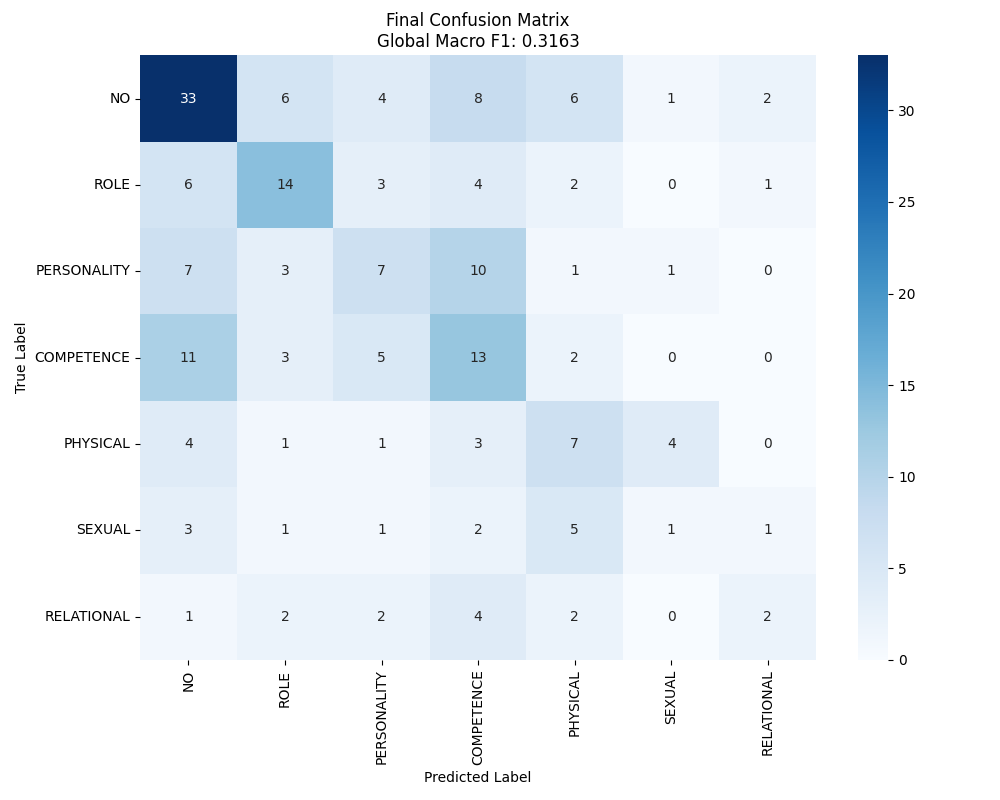

# **5. La Svolta: Few-Shot Learning con SetFit**
Preso atto che BERT standard richiedeva troppi dati, siamo passati a SetFit (Sentence Transformer Fine-tuning).
SetFit è progettato specificamente per scenari Few-Shot:

Fine-tuning Contrastivo: Addestra un Sentence Transformer a generare embedding vicini per esempi della stessa classe e lontani per classi diverse (usando coppie/triplette di frasi).

Classification Head: Addestra un classificatore leggero sugli embedding generati.

Questo approccio sfrutta molto meglio la conoscenza pregressa del modello linguistico.

In [ ]:
# Installazione libreire corrette
!pip uninstall -y transformers setfit peft huggingface_hub
!pip install -q "huggingface_hub<0.24.0" "transformers==4.41.2" "peft==0.11.1" "setfit==1.0.3" "sentence-transformers==3.0.0" "datasets" "accelerate" "scikit-learn"

print("Installazione Completata.")

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
Found existing installation: huggingface_hub 1.4.1
Uninstalling huggingface_hub-1.4.1:
  Successfully uninstalled huggingface_hub-1.4.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.9/75.9 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 402.8/402.8 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.3 MB/s eta 0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Caricamento dataset
   Dati Reali: 194 | Dati Sintetici: 280

 TRAINING FOLD 1/5
   ------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 514.


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)


 Modello fold 1 salvato correttamente.
Grafico salvato in: /content/drive/My Drive/Colab Notebooks/models_output/fold_1/loss_curve_fold_1.png


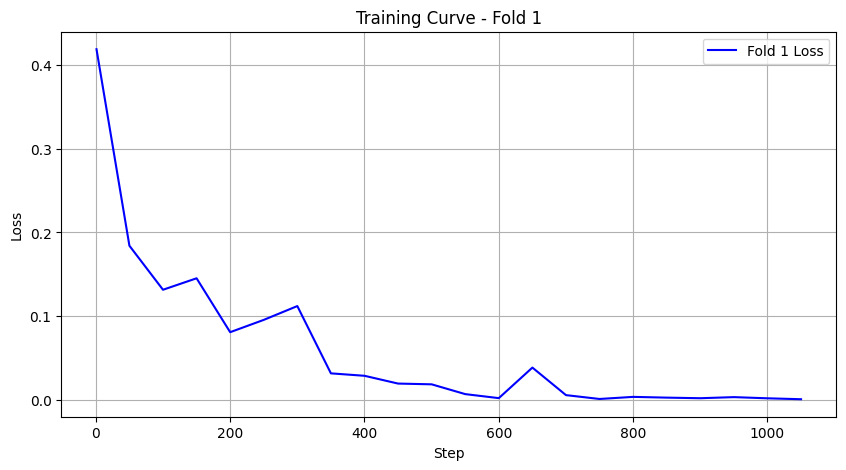


 TRAINING FOLD 2/5
   ------------------------------


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/datasets/utils/_dill.py:385: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


Map:   0%|          | 0/435 [00:00<?, ? examples/s]

Addestramento


***** Running training *****
  Num unique pairs = 17400
  Batch size = 16
  Num epochs = 1
  Total optimization steps = 1088


Step,Training Loss


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 514.


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/28 [00:00<?, ?it/s]

 Modello fold 2 salvato correttamente.
Grafico salvato in: /content/drive/My Drive/Colab Notebooks/models_output/fold_2/loss_curve_fold_2.png


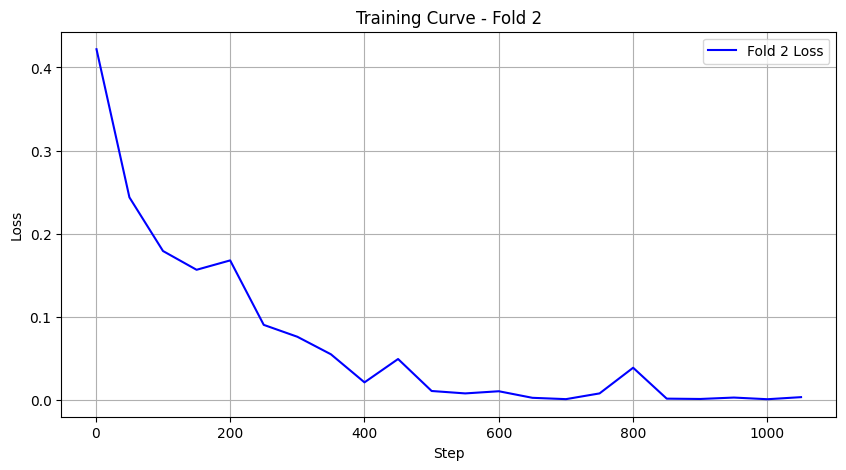


 TRAINING FOLD 3/5
   ------------------------------


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/435 [00:00<?, ? examples/s]

Addestramento


***** Running training *****
  Num unique pairs = 17400
  Batch size = 16
  Num epochs = 1
  Total optimization steps = 1088


Step,Training Loss


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 514.


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/28 [00:00<?, ?it/s]

 Modello fold 3 salvato correttamente.
Grafico salvato in: /content/drive/My Drive/Colab Notebooks/models_output/fold_3/loss_curve_fold_3.png


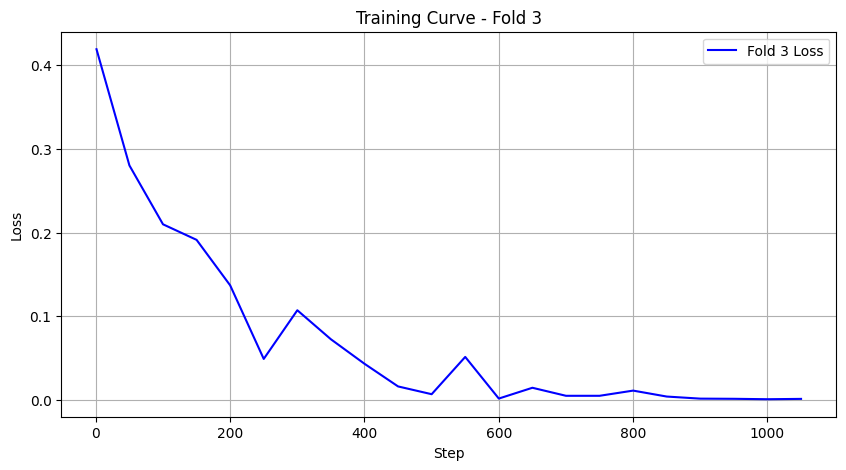


 TRAINING FOLD 4/5
   ------------------------------


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/435 [00:00<?, ? examples/s]

Addestramento


***** Running training *****
  Num unique pairs = 17400
  Batch size = 16
  Num epochs = 1
  Total optimization steps = 1088


Step,Training Loss


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 514.


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/28 [00:00<?, ?it/s]

 Modello fold 4 salvato correttamente.
Grafico salvato in: /content/drive/My Drive/Colab Notebooks/models_output/fold_4/loss_curve_fold_4.png


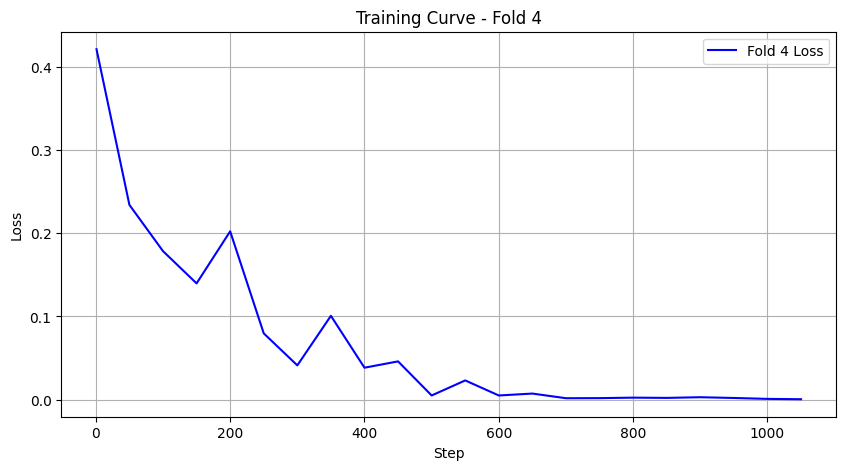


 TRAINING FOLD 5/5
   ------------------------------


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.


Map:   0%|          | 0/436 [00:00<?, ? examples/s]

Addestramento


***** Running training *****
  Num unique pairs = 17440
  Batch size = 16
  Num epochs = 1
  Total optimization steps = 1090


Step,Training Loss


The `max_length` is `None`. Using the maximum acceptable length according to the current model body: 514.


Epoch:   0%|          | 0/1 [00:00<?, ?it/s]

Iteration:   0%|          | 0/28 [00:00<?, ?it/s]

 Modello fold 5 salvato correttamente.
Grafico salvato in: /content/drive/My Drive/Colab Notebooks/models_output/fold_5/loss_curve_fold_5.png


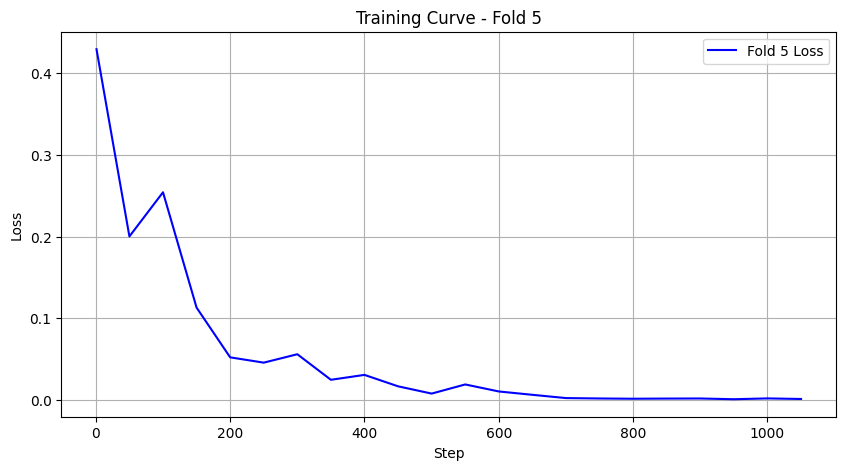


 TUTTI I FOLD COMPLETATI CON SUCCESSO!


In [ ]:
# 1. IMPORT LIBRERIE
import os
import json
import pandas as pd
import torch
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import StratifiedKFold
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from sentence_transformers import SentenceTransformer

# 2. SETUP AMBIENTE E PERCORSI

drive.mount('/content/drive')
PROJECT_PATH = "/content/drive/My Drive/Colab Notebooks"
OUTPUT_DIR   = os.path.join(PROJECT_PATH, "models_output")

if not os.path.exists(PROJECT_PATH):
    os.makedirs(PROJECT_PATH)

# Imposta la directory di lavoro
os.chdir(PROJECT_PATH)

# 3. CONFIGURAZIONE GLOBALE
RANDOM_STATE = 42
N_FOLDS      = 5
MODEL_ID     = "Musixmatch/umberto-commoncrawl-cased-v1"

# File Dataset
REAL_DATA = os.path.join(PROJECT_PATH, "dataset.jsonl")
SYN_DATA  = os.path.join(PROJECT_PATH, "synthetic.jsonl")

# Mappatura Etichette
LABEL_MAP = {
    "no": 0, "role": 1, "personality": 2, "competence": 3,
    "physical": 4, "sexual": 5, "relational": 6
}
CLASS_NAMES = [
    "NO", "ROLE", "PERSONALITY", "COMPETENCE",
    "PHYSICAL", "SEXUAL", "RELATIONAL"
]

# 4. FUNZIONI DI UTILITÀ

def load_data(path):
    """
    Carica i dati da un file JSONL, gestisce errori di parsing
    e mappa le etichette stringa in ID numerici.
    """
    data = []

    # Controllo esistenza file
    if not os.path.exists(path):
        print(f"Errore: File {path} non trovato!")
        return pd.DataFrame()

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue # Salta righe vuote
            try:
                item = json.loads(line)
                # Pulizia testo
                text_val = str(item.get('text', '')).replace('\n', ' ')
                # Normalizzazione label
                raw_label = str(item.get('gs_category', 'no')).lower()
                label_id = LABEL_MAP.get(raw_label, 0)

                data.append({"text": text_val, "label": label_id})
            except Exception:
                continue # Salta righe corrotte

    return pd.DataFrame(data)

def plot_training_loss(log_history, fold_num, save_dir):
    """
    Estrae la loss dai log del trainer, genera il grafico
    e lo salva nella directory del fold corrente.
    """
    losses = []
    steps = []

    # Estrazione metriche (supporta diverse chiavi di loss)
    for entry in log_history:
        if 'loss' in entry:
            losses.append(entry['loss'])
            steps.append(entry['step'])
        elif 'embedding_loss' in entry:
            losses.append(entry['embedding_loss'])
            steps.append(entry['step'])

    if not losses:
        return

    # Creazione Plot
    plt.figure(figsize=(10, 5))
    plt.plot(steps, losses, label=f'Fold {fold_num} Loss', color='blue')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title(f'Training Curve - Fold {fold_num}')
    plt.legend()
    plt.grid(True)

    # Salvataggio
    plot_path = os.path.join(save_dir, f"loss_curve_fold_{fold_num}.png")
    plt.savefig(plot_path)
    print(f"Grafico salvato in: {plot_path}")
    plt.show()
    plt.close()

# 5. MAIN LOOP

def main():

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    # --- Caricamento Dati ---
    print(f"Caricamento dataset")
    df_real = load_data(REAL_DATA)
    df_syn = load_data(SYN_DATA)

    if df_real.empty:
        print("Dataset reale vuoto o non valido. Interruzione.")
        return

    print(f"   Dati Reali: {len(df_real)} | Dati Sintetici: {len(df_syn)}")

    # Inizializzazione Cross-Validation
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    # --- Training Loop (Per ogni Fold) ---
    for fold, (train_idx, _) in enumerate(skf.split(df_real['text'], df_real['label'])):
        print(f"\n TRAINING FOLD {fold+1}/{N_FOLDS}")
        print("   " + "-"*30)

        # Preparazione dati train (Real subset + Synthetic full)
        train_real = df_real.iloc[train_idx]
        train_combined = pd.concat([train_real, df_syn]).sample(frac=1, random_state=RANDOM_STATE)
        train_ds = Dataset.from_pandas(train_combined)

        # Inizializzazione Modello SetFit
        model = SetFitModel.from_pretrained(
            MODEL_ID,
            labels=CLASS_NAMES,
            use_differentiable_head=True,
            head_params={"out_features": len(CLASS_NAMES)},
        )

        # Argomenti Addestramento
        args = TrainingArguments(
            batch_size=16,
            num_epochs=1,
            num_iterations=20,
            save_strategy="no",
            report_to="none"
        )

        # FIX COMPATIBILITÀ:
        # Assicura compatibilità con le versioni recenti di Transformers/SetFit
        if not hasattr(args, "eval_strategy"):
            args.eval_strategy = args.evaluation_strategy

        # Inizializzazione Trainer
        trainer = Trainer(
            model=model,
            args=args,
            train_dataset=train_ds
        )

        # Avvio Addestramento
        print("Addestramento")
        trainer.train()

        # Salvataggio Modello per il Fold corrente
        fold_dir = os.path.join(OUTPUT_DIR, f"fold_{fold+1}")
        model.save_pretrained(fold_dir)

        # Salvataggio Log e Generazione Grafici
        log_history = trainer.state.log_history
        with open(os.path.join(fold_dir, "training_logs.json"), "w") as f:
            json.dump(log_history, f)

        print(f" Modello fold {fold+1} salvato correttamente.")
        plot_training_loss(log_history, fold+1, fold_dir)

    print("\n TUTTI I FOLD COMPLETATI CON SUCCESSO!")

if __name__ == "__main__":
    main()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Caricamento dataset per valutazione
Avvio valutazione su 5 Fold
 Processing FOLD 1...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


 Processing FOLD 2...
 Processing FOLD 3...
 Processing FOLD 4...
 Processing FOLD 5...

RISULTATI AGGREGATI (Cross-Validation)

ACCURACY GLOBALE:    0.5979
F1-SCORE (MACRO):     0.6281
F1-SCORE (WEIGHTED):  0.5929

DETTAGLIO PER CLASSE:
              precision    recall  f1-score   support

          NO     0.5682    0.4167    0.4808        60
        ROLE     0.6667    0.7143    0.6897        28
 PERSONALITY     0.4571    0.5714    0.5079        28
  COMPETENCE     0.6486    0.7742    0.7059        31
    PHYSICAL     0.5217    0.6000    0.5581        20
      SEXUAL     0.8889    0.5714    0.6957        14
  RELATIONAL     0.6875    0.8462    0.7586        13

    accuracy                         0.5979       194
   macro avg     0.6341    0.6420    0.6281       194
weighted avg     0.6056    0.5979    0.5929       194



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


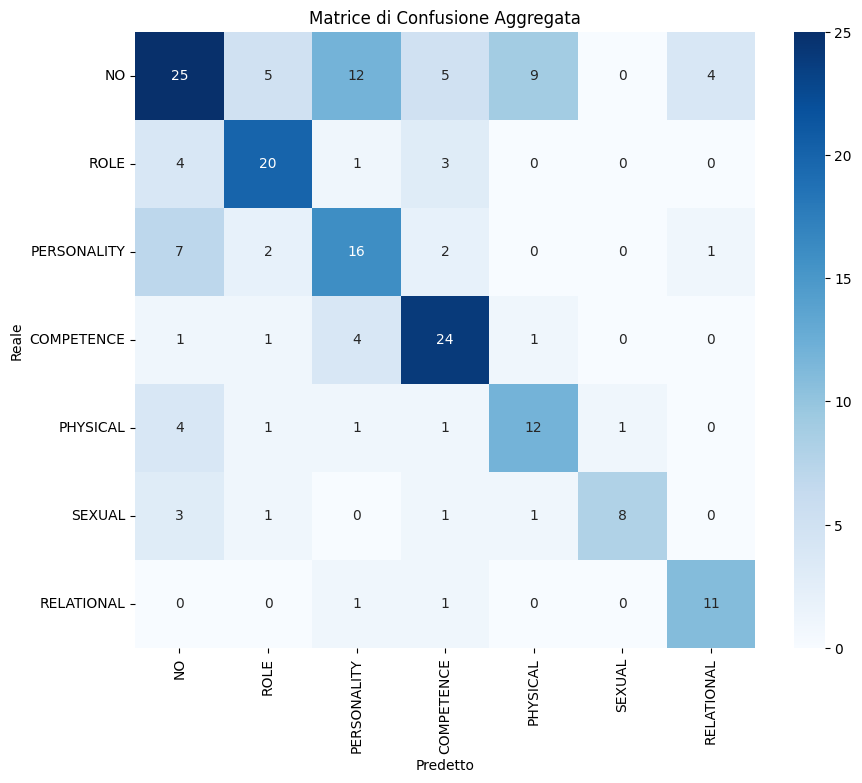


ANALISI ERRORI CON LIVELLO DI CONFIDENZA (Primi 25):
---------------------------------------------------------------------------------------------------------------------------------------
REALE         | PREDETTO      | CONFIDENZA | TESTO
---------------------------------------------------------------------------------------------------------------------------------------
NO            | COMPETENCE    | 99.0%      | Le nostre ragazze hanno tenuto alto il nome dell'Italia nel calcio a differenza degli...
NO            | ROLE          | 100.0%     | Beh cosa dire ...la mamma è la mamma da sempre nei secoli dei secoli.. E difficile sp...
NO            | ROLE          | 99.9%      | Essere mamma è comunque un DONO, una GRAZIA che non è di tutte le donne, se pure hann...
PHYSICAL      | NO            | 99.9%      | [Commento ad articolo con titolo "😔 Si ferma in semifinale l'avventura di Errani e Pa...
NO            | RELATIONAL    | 57.2%      | adesso i calciatori sono viziati,troppi so

In [ ]:
# 1. IMPORT LIBRERIE
import os
import json
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from setfit import SetFitModel

# 2. SETUP AMBIENTE E PERCORSI

drive.mount('/content/drive')
PROJECT_PATH = "/content/drive/My Drive/Colab Notebooks"
OUTPUT_DIR   = os.path.join(PROJECT_PATH, "models_output")

# Verifica directory progetto
if not os.path.exists(PROJECT_PATH):
    print(f"ATTENZIONE: La directory {PROJECT_PATH} non esiste.")

# Imposta la directory di lavoro
try:
    os.chdir(PROJECT_PATH)
except FileNotFoundError:
    pass

# 3. CONFIGURAZIONE GLOBALE
RANDOM_STATE = 42
N_FOLDS      = 5

# File Dataset
REAL_DATA = os.path.join(PROJECT_PATH, "dataset.jsonl")

# Mappatura Etichette
LABEL_MAP = {
    "no": 0, "role": 1, "personality": 2, "competence": 3,
    "physical": 4, "sexual": 5, "relational": 6
}
# Generazione inversa automatica (ID -> Label)
ID2LABEL = {v: k.upper() for k, v in LABEL_MAP.items()}
CLASS_NAMES = [ID2LABEL[i] for i in range(len(ID2LABEL))]

# 4. FUNZIONI DI UTILITÀ

def load_data(path):
    """
    Carica i dati dal file JSONL, gestisce il parsing e mappa le label.
    """
    data = []
    if not os.path.exists(path):
        print(f"Errore: File {path} non trovato!")
        return pd.DataFrame()

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            if not line.strip(): continue
            try:
                item = json.loads(line)
                data.append({
                    "text": str(item.get('text', '')).replace('\n', ' '),
                    "label": LABEL_MAP.get(str(item.get('gs_category', 'no')).lower(), 0)
                })
            except Exception:
                continue
    return pd.DataFrame(data)

def print_confusion_matrix(y_true, y_pred, classes):
    """
    Genera e visualizza la matrice di confusione.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.ylabel('Reale')
    plt.xlabel('Predetto')
    plt.title('Matrice di Confusione Aggregata')
    plt.show()

def print_error_analysis(texts, true_labels, pred_labels, confidences, limit=25):
    """
    Stampa un report dettagliato degli errori commessi dal modello.
    """
    print("\nANALISI ERRORI CON LIVELLO DI CONFIDENZA (Primi 25):")
    print("-" * 135)
    print(f"{'REALE':<13} | {'PREDETTO':<13} | {'CONFIDENZA':<10} | {'TESTO'}")
    print("-" * 135)

    err_count = 0
    for t, true, pred, conf in zip(texts, true_labels, pred_labels, confidences):
        if true != pred:
            conf_percent = f"{conf*100:.1f}%"
            # Taglia il testo se troppo lungo per la visualizzazione
            text_preview = (t[:85] + '...') if len(t) > 85 else t
            print(f"{ID2LABEL[true]:<13} | {ID2LABEL[pred]:<13} | {conf_percent:<10} | {text_preview}")
            err_count += 1
            if err_count >= limit: break

# 5. MAIN LOOP (VALUTAZIONE)

def main_evaluation():

    print("Caricamento dataset per valutazione")
    df = load_data(REAL_DATA)
    if df.empty: return

    # Liste per accumulare i risultati di tutti i fold
    metrics_store = {
        "texts": [],
        "true_labels": [],
        "pred_labels": [],
        "confidences": []
    }

    # Setup Cross-Validation (deve essere identico al training)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    print(f"Avvio valutazione su {N_FOLDS} Fold")

    # --- Ciclo sui Fold ---
    for fold, (_, test_idx) in enumerate(skf.split(df['text'], df['label'])):
        fold_num = fold + 1
        print(f" Processing FOLD {fold_num}...")

        # Selezione Test Set per questo fold
        test_df = df.iloc[test_idx]
        X_test = test_df['text'].tolist()
        y_test = test_df['label'].tolist()

        # Percorso del modello specifico per questo fold
        model_path = os.path.join(OUTPUT_DIR, f"fold_{fold_num}")
        if not os.path.exists(model_path):
            print(f"    Modello non trovato in: {model_path}. Salto il fold.")
            continue

        # Caricamento Modello
        model = SetFitModel.from_pretrained(model_path)
        if torch.cuda.is_available():
            model.to("cuda")

        # 1. Inferenza
        raw_preds = model.predict(X_test)
        probs_output = model.predict_proba(X_test)

        # 2. Conversione Tensor -> Numpy (Gestione compatibilità)
        if torch.is_tensor(probs_output):
            probs = probs_output.detach().cpu().numpy()
        else:
            probs = np.array(probs_output)

        # 3. Elaborazione risultati batch
        batch_preds = []
        batch_confs = []

        for i, p in enumerate(raw_preds):
            p_str = str(p).lower().strip()
            pred_id = LABEL_MAP.get(p_str, 0) # Fallback a 0 se non trova label
            batch_preds.append(pred_id)
            # Max probabilità come confidenza
            batch_confs.append(float(np.max(probs[i])))

        # 4. Aggiornamento store globale
        metrics_store["texts"].extend(X_test)
        metrics_store["true_labels"].extend(y_test)
        metrics_store["pred_labels"].extend(batch_preds)
        metrics_store["confidences"].extend(batch_confs)

        # Pulizia memoria GPU
        del model
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # --- REPORT FINALE AGGREGATO ---
    print("\n" + "="*75)
    print("RISULTATI AGGREGATI (Cross-Validation)")
    print("="*75)

    all_true = metrics_store["true_labels"]
    all_pred = metrics_store["pred_labels"]

    if not all_true:
        print("Nessun dato valutato.")
        return

    # Calcolo Metriche
    acc = accuracy_score(all_true, all_pred)
    f1_macro = f1_score(all_true, all_pred, average='macro')
    f1_weighted = f1_score(all_true, all_pred, average='weighted')

    print(f"\nACCURACY GLOBALE:    {acc:.4f}")
    print(f"F1-SCORE (MACRO):     {f1_macro:.4f}")
    print(f"F1-SCORE (WEIGHTED):  {f1_weighted:.4f}")

    print("\nDETTAGLIO PER CLASSE:")
    print(classification_report(all_true, all_pred, target_names=CLASS_NAMES, digits=4))

    # Visualizzazioni
    print_confusion_matrix(all_true, all_pred, CLASS_NAMES)

    print_error_analysis(
        metrics_store["texts"],
        all_true,
        all_pred,
        metrics_store["confidences"]
    )

if __name__ == "__main__":
    main_evaluation()

# **6. Valutazione e Raffinamento Pipeline**
I risultati di SetFit hanno portato un miglioramento drastico (F1 ~0.62 vs 0.35 di BERT). Tuttavia, persiste una leggera confusione tra la classe NO e gli stereotipi.

Abbiamo tentato un ultimo raffinamento: una Pipeline a Cascata.

Modello Binario: Addestrato solo per decidere se un testo è Stereotipo o NO.

Modello Multiclasse: Attivato solo se il binario predice "Stereotipo".

Questo modello però non migliorava tanto questo aspetto e anzi peggiorava l'F1 score

# **7. Conclusioni**
Il nostro percorso sperimentale ha evidenziato che in contesti di Small Data:

I modelli pesanti (BERT standard) tendono all'overfitting, anche con tecniche di regolarizzazione come la Knowledge Distillation.

L'analisi degli errori (Confidence Analysis) è fondamentale per capire se il modello sta imparando o solo tirando a indovinare con alta confidenza.

L'approccio Contrastive Learning (SetFit) si è rivelato la soluzione vincente, permettendo al modello di apprendere distanze semantiche efficaci anche con pochissimi esempi per classe.

La pipeline finale raggiunge un Macro F1 di ~0.61, un risultato robusto considerando la dimensione esigua del dataset di partenza.